### Extract, Trasform, Load (ETL)

In [752]:
import pandas as pd

In [753]:
df = pd.read_csv("..\..\data\Patch13_3\Professional\patch13_3data.csv", low_memory=False)

___
### Exploratoty Data Analysis (EDA)

In [754]:
df.head(3)

,gameId,team,summoner,region,champion,timestamp,coordinate_x,coordinate_y,level,minionsKilled,...,trueDamageDoneToChampions,trueDamageTaken,victory,eventType,skillSlot,buildingType,lane,monster,itemName,role
0,EUW1_6272362521,Blue,anonymous 2,euw1,Akshan,0.000000,554.0,581.0,1.0,0.0,...,0.0,0.0,False,NaN,NaN,NaN,NaN,NaN,NaN,TOP
1,EUW1_6272362521,Blue,anonymous 2,euw1,Akshan,1.000300,3177.0,8848.0,1.0,0.0,...,0.0,0.0,False,NaN,NaN,NaN,NaN,NaN,NaN,TOP
2,EUW1_6272362521,Blue,anonymous 2,euw1,Akshan,2.000733,2665.0,13301.0,1.0,2.0,...,0.0,0.0,False,NaN,NaN,NaN,NaN,NaN,NaN,TOP


In [755]:
df.shape

(392071, 55)

In [756]:
df.dtypes

gameId                            object
team                              object
summoner                          object
region                            object
champion                          object
timestamp                        float64
coordinate_x                     float64
coordinate_y                     float64
level                            float64
minionsKilled                    float64
jungleMinionsKilled              float64
currentGold                      float64
goldPerSecond                    float64
totalGold                        float64
xp                               float64
abilityPower                     float64
armor                            float64
armorPen                         float64
armorPenPercent                  float64
attackDamage                     float64
attackSpeed                      float64
ccReduction                      float64
health                           float64
healthMax                        float64
healthRegen     

In [757]:
df.isnull().sum()

gameId                                0
team                                  0
summoner                              0
region                                0
champion                              0
timestamp                             0
coordinate_x                     174453
coordinate_y                     174453
level                            261168
minionsKilled                    261168
jungleMinionsKilled              261168
currentGold                      261168
goldPerSecond                    261168
totalGold                        261168
xp                               261168
abilityPower                     261168
armor                            261168
armorPen                         261168
armorPenPercent                  261168
attackDamage                     261168
attackSpeed                      261168
ccReduction                      261168
health                           261168
healthMax                        261168
healthRegen                      261168


In [758]:
df.columns

Index(['gameId', 'team', 'summoner', 'region', 'champion', 'timestamp',
       'coordinate_x', 'coordinate_y', 'level', 'minionsKilled',
       'jungleMinionsKilled', 'currentGold', 'goldPerSecond', 'totalGold',
       'xp', 'abilityPower', 'armor', 'armorPen', 'armorPenPercent',
       'attackDamage', 'attackSpeed', 'ccReduction', 'health', 'healthMax',
       'healthRegen', 'lifesteal', 'magicPen', 'magicPenPercent',
       'magicResist', 'movementSpeed', 'omnivamp', 'power', 'powerMax',
       'powerRegen', 'spellVamp', 'magicDamageDone',
       'magicDamageDoneToChampions', 'magicDamageTaken', 'physicalDamageDone',
       'physicalDamageDoneToChampions', 'physicalDamageTaken',
       'totalDamageDone', 'totalDamageDoneToChampions', 'totalDamageTaken',
       'trueDamageDone', 'trueDamageDoneToChampions', 'trueDamageTaken',
       'victory', 'eventType', 'skillSlot', 'buildingType', 'lane', 'monster',
       'itemName', 'role'],
      dtype='object')

In [759]:
df['eventType'].unique()

array([nan, 'SkillLevelUp', 'Death', 'Assist', 'Elite Monster Kill',
       'Building Kill', 'Item purchased'], dtype=object)

In [760]:
(df['eventType'] == 'Death').sum()

24838

- Here i had to fill the missing values

In [761]:
cols_to_fill = [
    'level', 'minionsKilled', 'jungleMinionsKilled', 'currentGold', 'totalGold', 
    'totalDamageDoneToChampions', 'totalDamageTaken', 'trueDamageTaken', 'armor',
    'health', 'healthMax', 'movementSpeed', 'healthRegen', 'totalDamageDone'
]

# Propagate stats using groupby and ffill (no sorting needed)
df[cols_to_fill] = df.groupby(['gameId', 'summoner'])[cols_to_fill].ffill()

# Filter to retain only death events
df_deaths = df[df['eventType'] == 'Death'].copy()
df_deaths.shape

(24838, 55)

In [762]:
df_deaths.head(2)

,gameId,team,summoner,region,champion,timestamp,coordinate_x,coordinate_y,level,minionsKilled,...,trueDamageDoneToChampions,trueDamageTaken,victory,eventType,skillSlot,buildingType,lane,monster,itemName,role
17,EUW1_6272362521,Blue,anonymous 2,euw1,Akshan,8.117383,1056.0,11970.0,7.0,63.0,...,NaN,42.0,False,Death,NaN,NaN,NaN,NaN,NaN,TOP
21,EUW1_6272362521,Blue,anonymous 2,euw1,Akshan,10.668300,2696.0,12894.0,8.0,77.0,...,NaN,42.0,False,Death,NaN,NaN,NaN,NaN,NaN,TOP


___
### Data Transformation for Supervised Learning:
- Since Random Forest is a classifier, I need a target variable to predict. I will create this by dividing the map into 16 regions or zones based in coordinades when the player died. The variable will be called `death_square`.

- FILTERING only for the Jungler

In [763]:
cols_to_keep = [
    'role', 'team', 'coordinate_x', 'coordinate_y', 'level', 'minionsKilled',
    'jungleMinionsKilled', 'totalGold', 'totalDamageDoneToChampions',
    'totalDamageTaken', 'trueDamageTaken', 'health', 'healthMax',
    'movementSpeed', 'healthRegen', 'totalDamageDone']

cond = (df_deaths['role'] == 'JUNGLE') & \
       df_deaths['coordinate_x'].notnull() & \
       df_deaths['coordinate_y'].notnull()

for col in cols_to_keep:
    if col not in ['role', 'coordinate_x', 'coordinate_y']:
        cond &= df_deaths[col].notnull()
        
df_jungler_all = df_deaths[cond].copy()
df_jungler_all = df_jungler_all[cols_to_keep]
df_jungler_all.head(2)

,role,team,coordinate_x,coordinate_y,level,minionsKilled,jungleMinionsKilled,totalGold,totalDamageDoneToChampions,totalDamageTaken,trueDamageTaken,health,healthMax,movementSpeed,healthRegen,totalDamageDone
5915,JUNGLE,Red,8286.0,7654.0,4.0,5.0,20.0,2179.0,1563.0,3525.0,159.0,882.0,882.0,345.0,18.0,15876.0
5938,JUNGLE,Red,10048.0,8002.0,10.0,24.0,79.0,6680.0,9485.0,14332.0,363.0,1457.0,1457.0,400.0,25.0,95553.0


In [764]:
df_jungler_all.shape

(4255, 16)

In [765]:
# Define map and grid parameters
map_size = 16000
grid_size = 4
square_size = map_size // grid_size  # 4000 units per square


# Calculate column and row indices using floor division and clip to handle boundaries
df_jungler_all['col'] = (df_jungler_all['coordinate_x'] // square_size).astype(int).clip(0, grid_size - 1)
df_jungler_all['row'] = (df_jungler_all['coordinate_y'] // square_size).astype(int).clip(0, grid_size - 1)


# Calculate the Square_coordinate index
df_jungler_all['death_square'] = df_jungler_all['row'] * grid_size + df_jungler_all['col']

df_jungler_all.drop(['col', 'row'], axis=1, inplace=True)
df_jungler_all.head(2)

,role,team,coordinate_x,coordinate_y,level,minionsKilled,jungleMinionsKilled,totalGold,totalDamageDoneToChampions,totalDamageTaken,trueDamageTaken,health,healthMax,movementSpeed,healthRegen,totalDamageDone,death_square
5915,JUNGLE,Red,8286.0,7654.0,4.0,5.0,20.0,2179.0,1563.0,3525.0,159.0,882.0,882.0,345.0,18.0,15876.0,6
5938,JUNGLE,Red,10048.0,8002.0,10.0,24.0,79.0,6680.0,9485.0,14332.0,363.0,1457.0,1457.0,400.0,25.0,95553.0,10


In [766]:
df_jungler_team_RED = df_jungler_all[df_jungler_all['team'] == 'Red'].copy()
df_jungler_team_BLUE = df_jungler_all[df_jungler_all['team'] == 'Blue'].copy()

print(df_jungler_team_BLUE.shape, df_jungler_team_RED.shape)

(1896, 17) (2359, 17)


___
## PLOT

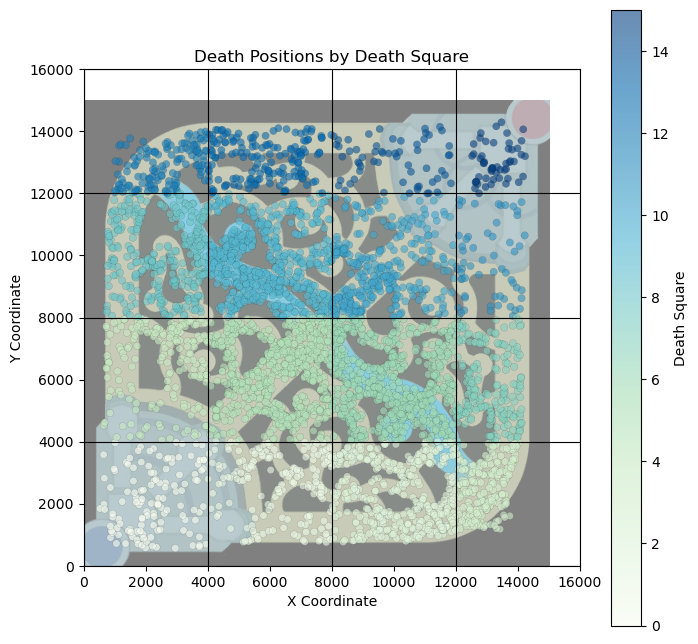

In [767]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# Import League of Legends map image
map_image_path = '..\..\data\images\league_of_legends_map\map.png'
fig, ax = plt.subplots(figsize=(8, 8))
try:
    map_img = mpimg.imread(map_image_path)
    ax.imshow(map_img, extent=[0, 15000, 0, 15000], alpha=0.5)
except FileNotFoundError:
    print("Map image not found. Plotting without background.")

scatter = plt.scatter(
    df_jungler_all['coordinate_x'], 
    df_jungler_all['coordinate_y'], 
    c = df_jungler_all['death_square'], 
    cmap='GnBu',   # or any other colormap
    s= 28,          # size of points
    alpha=0.6,
    edgecolor='k',
    linewidth=0.1
)

x_min, x_max = 0, 16000
y_min, y_max = 0, 16000
n_squares = 4
x_ticks = np.linspace(x_min, x_max, n_squares+1)
y_ticks = np.linspace(y_min, y_max, n_squares+1)
# Vertical lines
for x in x_ticks:
    ax.axvline(x, color='black', lw= 0.8)
# Horizontal lines
for y in y_ticks:
    ax.axhline(y, color='black', lw= 0.8)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

cbar = plt.colorbar(scatter)
cbar.set_label('Death Square')

plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("Death Positions by Death Square")
plt.show()


___

In [768]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

coords = df_jungler_all[['coordinate_x','coordinate_y']]
X = df_jungler_all.drop(columns = ['death_square', 'team', 'role', 'coordinate_x', 'coordinate_y'], axis=1)
Y = df_jungler_all['death_square']

X_train, X_test, y_train, y_test, coord_train, coord_test = train_test_split(
    X, Y, coords, test_size=0.2, random_state=8)

In [769]:
rf_reg = RandomForestRegressor(
    n_estimators=1000,
    max_depth=40,
    n_jobs=6,
    random_state= 8
)

rf_reg.fit(X_train, y_train)

RandomForestRegressor(max_depth=40, n_estimators=1000, n_jobs=6, random_state=8)

In [770]:
y_pred = rf_reg.predict(X_test)

In [771]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MAE: 2.8541853877840455
MSE: 12.439932332133694
R²: -0.02223444289865717


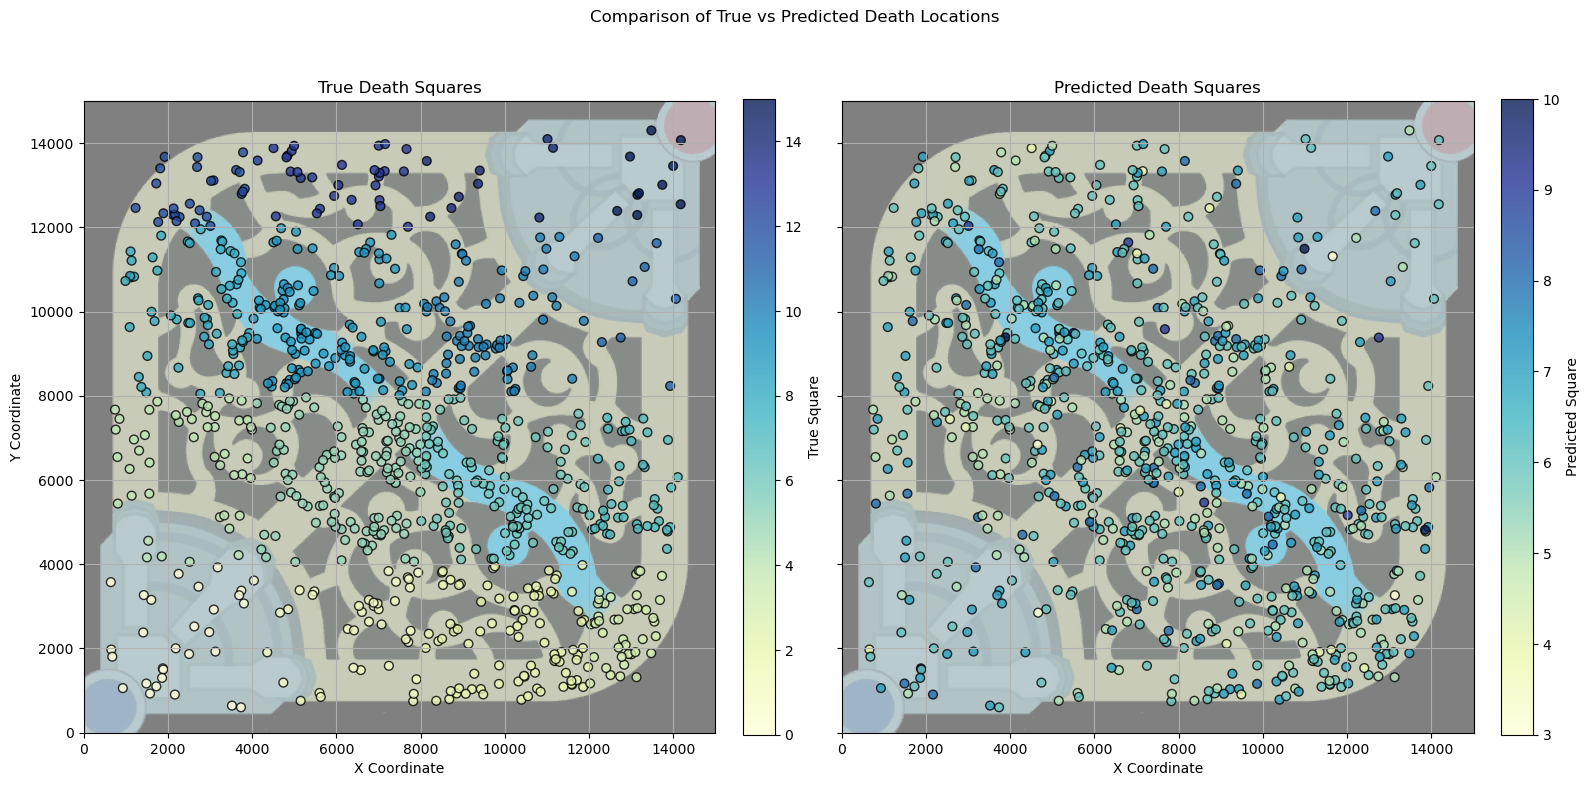

In [772]:
df_plot = coord_test.copy()
df_plot['true_sq'] = y_test.astype(int)
df_plot['pred_sq'] = y_pred.astype(int)

# Create side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)


try:    # Loading the map image
    map_img = mpimg.imread(map_image_path)
    extent = [0, 15000, 0, 15000]
except FileNotFoundError:
    map_img = None

# --- Left: True squares ---
if map_img is not None:
    ax1.imshow(map_img, extent=extent, alpha=0.5)
sc1 = ax1.scatter(
    df_plot.coordinate_x,
    df_plot.coordinate_y,
    c=df_plot.true_sq,
    cmap='YlGnBu',
    s=40,
    alpha=0.8,
    edgecolors='k'
)
ax1.set_title("True Death Squares")
ax1.set_xlabel("X Coordinate")
ax1.set_ylabel("Y Coordinate")
cb1 = fig.colorbar(sc1, ax=ax1, fraction=0.046, pad=0.04)
cb1.set_label('True Square')
ax1.grid(True)

# --- Right: Predicted squares ---
if map_img is not None:
    ax2.imshow(map_img, extent=extent, alpha=0.5)
sc2 = ax2.scatter(
    df_plot.coordinate_x,
    df_plot.coordinate_y,
    c=df_plot.pred_sq,
    cmap='YlGnBu',
    s=40,
    alpha=0.8,
    edgecolors='k'
)
ax2.set_title("Predicted Death Squares")
ax2.set_xlabel("X Coordinate")
# no need to set ylabel again for the second plot if sharey=True
cb2 = fig.colorbar(sc2, ax=ax2, fraction=0.046, pad=0.04)
cb2.set_label('Predicted Square')
ax2.grid(True)

plt.suptitle("Comparison of True vs Predicted Death Locations")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
